# Классификация эмоций: Нейтральная vs Ненейтральная

Сравниваем три подхода на датасете **RAVDESS**:
1. **DistilHuBERT → Linear Classifier** — трансферное обучение с предобученным аудио-энкодером
2. **Log-Mel Spectrogram → CNN** — 2D-свёрточная сеть на спектрограммах
3. **MFCC → SVM** — классический ML-подход

Метрики сравнения:
- **Качество** — Accuracy, F1 (macro), Precision, Recall
- **Скорость** — время инференса на одном файле (end-to-end)
- **Размер модели** — объём классификатора и всего пайплайна

In [1]:
import os, io, pickle, time, gc

import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report,
)

from transformers import AutoModel, Wav2Vec2FeatureExtractor

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

SR = 16000
results = []


def pytorch_size_mb(model):
    b = sum(p.numel() * p.element_size() for p in model.parameters())
    b += sum(x.numel() * x.element_size() for x in model.buffers())
    return b / 1024 ** 2


def sklearn_size_mb(model):
    buf = io.BytesIO()
    pickle.dump(model, buf)
    return buf.tell() / 1024 ** 2

Device: mps


## Загрузка данных RAVDESS

In [2]:
RAVDESS_PATH = "../datasets/orvile/ravdess-dataset/versions/1/"
audio_base = os.path.join(RAVDESS_PATH, "Audio_Speech_Actors_01-24")

file_paths, labels, actors = [], [], []
for actor_dir in sorted(os.listdir(audio_base)):
    if not actor_dir.startswith("Actor_"):
        continue
    for f in sorted(os.listdir(os.path.join(audio_base, actor_dir))):
        if not f.endswith(".wav"):
            continue
        fp = os.path.join(audio_base, actor_dir, f)
        emotion = int(os.path.basename(f).split('-')[2])
        file_paths.append(fp)
        labels.append(0 if emotion <= 2 else 1)  # 0=neutral/calm, 1=emotional
        actors.append(int(actor_dir.split('_')[1]))

labels = np.array(labels)
actors = np.array(actors)

# Speaker-independent split: последние 20 % актёров → test
unique_actors = sorted(set(actors))
test_actors = set(unique_actors[-max(1, len(unique_actors) // 5):])

train_idx = [i for i, a in enumerate(actors) if a not in test_actors]
test_idx  = [i for i, a in enumerate(actors) if a in test_actors]

train_files = [file_paths[i] for i in train_idx]
test_files  = [file_paths[i] for i in test_idx]
y_train, y_test = labels[train_idx], labels[test_idx]

print(f"Файлов: {len(file_paths)} | Neutral: {(labels==0).sum()} | Emotional: {(labels==1).sum()}")
print(f"Train: {len(train_files)} (actors {sorted(set(actors[train_idx]))})")
print(f"Test:  {len(test_files)} (actors {sorted(test_actors)})")
print(f"Train balance — neutral: {(y_train==0).sum()}, emotional: {(y_train==1).sum()}")
print(f"Test  balance — neutral: {(y_test==0).sum()}, emotional: {(y_test==1).sum()}")

Файлов: 1440 | Neutral: 288 | Emotional: 1152
Train: 1200 (actors [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)])
Test:  240 (actors [np.int64(21), np.int64(22), np.int64(23), np.int64(24)])
Train balance — neutral: 240, emotional: 960
Test  balance — neutral: 48, emotional: 192


## Подход 1: audio → DistilHuBERT → Linear Classifier

In [3]:
HUBERT_NAME = "ntu-spml/distilhubert"
hub_extractor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_NAME)
hub_model = AutoModel.from_pretrained(HUBERT_NAME).to(device).eval()

hub_dim = hub_model.config.hidden_size
hub_params = sum(p.numel() for p in hub_model.parameters())
print(f"DistilHuBERT: hidden_size={hub_dim}, params={hub_params:,}")


def hubert_embed(path):
    y, _ = librosa.load(path, sr=SR)
    inp = hub_extractor(y, sampling_rate=SR, return_tensors="pt").to(device)
    with torch.no_grad():
        h = hub_model(**inp).last_hidden_state  # (1, T, hidden_size)
    return h.mean(dim=1).squeeze(0).cpu().numpy()  # (hidden_size,)


print("Извлечение DistilHuBERT-эмбеддингов...")
X_hub_train = np.array([hubert_embed(f) for f in tqdm(train_files)])
X_hub_test  = np.array([hubert_embed(f) for f in tqdm(test_files)])
print(f"Train: {X_hub_train.shape}, Test: {X_hub_test.shape}")

model.safetensors:   0%|          | 0.00/94.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/49 [00:00<?, ?it/s]

DistilHuBERT: hidden_size=768, params=23,491,968
Извлечение DistilHuBERT-эмбеддингов...


100%|██████████| 240/240 [00:05<00:00, 43.34it/s]

Train: (1200, 768), Test: (240, 768)


In [4]:
class LinearClassifier(nn.Module):
    def __init__(self, d, n_classes=2):
        super().__init__()
        self.fc = nn.Linear(d, n_classes)

    def forward(self, x):
        return self.fc(x)


model_1 = LinearClassifier(hub_dim).to(device)
opt1 = optim.Adam(model_1.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

ds1 = TensorDataset(
    torch.tensor(X_hub_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long),
)
loader1 = DataLoader(ds1, batch_size=32, shuffle=True)

t0 = time.time()
for ep in range(50):
    model_1.train()
    for xb, yb in loader1:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model_1(xb), yb)
        opt1.zero_grad()
        loss.backward()
        opt1.step()
    if (ep + 1) % 10 == 0:
        model_1.eval()
        with torch.no_grad():
            acc = (
                model_1(torch.tensor(X_hub_train, dtype=torch.float32).to(device))
                .argmax(1).cpu().numpy() == y_train
            ).mean()
        print(f"Epoch {ep+1}/50 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_1 = time.time() - t0

# End-to-end инференс
model_1.eval()
t0 = time.time()
preds_1 = []
for f in test_files:
    y_audio, _ = librosa.load(f, sr=SR)
    inp = hub_extractor(y_audio, sampling_rate=SR, return_tensors="pt").to(device)
    with torch.no_grad():
        emb = hub_model(**inp).last_hidden_state.mean(dim=1)
        preds_1.append(model_1(emb).argmax(1).item())
inf_time_1 = (time.time() - t0) / len(test_files)
preds_1 = np.array(preds_1)

hub_pipeline_mb = pytorch_size_mb(hub_model) + pytorch_size_mb(model_1)
cls_1_mb = pytorch_size_mb(model_1)

hub_model.cpu()
model_1.cpu()
del hub_model, hub_extractor
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
gc.collect()

results.append({
    "Модель": "DistilHuBERT + Linear",
    "Accuracy": accuracy_score(y_test, preds_1),
    "F1 (macro)": f1_score(y_test, preds_1, average="macro"),
    "Precision": precision_score(y_test, preds_1, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_1, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_1 * 1000,
    "Обучение (сек)": train_time_1,
    "Классификатор (MB)": cls_1_mb,
    "Пайплайн (MB)": hub_pipeline_mb,
})
print(f"\nDistilHuBERT + Linear → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_1*1000:.1f} мс/файл  Pipeline={hub_pipeline_mb:.1f} MB")

Epoch 10/50 | Loss 0.2633 | Train Acc 0.9075
Epoch 20/50 | Loss 0.2805 | Train Acc 0.9208
Epoch 30/50 | Loss 0.1347 | Train Acc 0.9342
Epoch 40/50 | Loss 0.1012 | Train Acc 0.9475
Epoch 50/50 | Loss 0.2221 | Train Acc 0.9508

DistilHuBERT + Linear → Acc=0.9500 F1=0.9206 Inf=22.8 мс/файл  Pipeline=89.6 MB


## Подход 2: audio → Log-Mel Spectrogram → CNN

In [5]:
N_MELS, MAX_LEN, HOP = 64, 128, 512


def extract_log_mel(path):
    y, _ = librosa.load(path, sr=SR)
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm = librosa.power_to_db(mel, ref=np.max)
    if lm.shape[1] < MAX_LEN:
        lm = np.pad(lm, ((0, 0), (0, MAX_LEN - lm.shape[1])))
    else:
        lm = lm[:, :MAX_LEN]
    return lm  # (N_MELS, MAX_LEN)


print("Извлечение log-mel спектрограмм...")
X_mel_train = np.array([extract_log_mel(f) for f in tqdm(train_files)])
X_mel_test  = np.array([extract_log_mel(f) for f in tqdm(test_files)])

mel_mean, mel_std = X_mel_train.mean(), X_mel_train.std()
X_mel_train = (X_mel_train - mel_mean) / (mel_std + 1e-8)
X_mel_test  = (X_mel_test  - mel_mean) / (mel_std + 1e-8)
print(f"Train: {X_mel_train.shape}, Test: {X_mel_test.shape}")

Извлечение log-mel спектрограмм...


100%|██████████| 240/240 [00:00<00:00, 320.53it/s]

Train: (1200, 64, 128), Test: (240, 64, 128)


In [6]:
class MelCNN(nn.Module):
    def __init__(self, n_mels=64, max_len=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (n_mels // 8) * (max_len // 8), 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model_2 = MelCNN(N_MELS, MAX_LEN).to(device)
print(f"CNN params: {sum(p.numel() for p in model_2.parameters()):,}")

ds2 = TensorDataset(
    torch.tensor(X_mel_train[:, None], dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long),
)
loader2 = DataLoader(ds2, batch_size=32, shuffle=True)
opt2 = optim.Adam(model_2.parameters(), lr=1e-3, weight_decay=1e-4)
crit2 = nn.CrossEntropyLoss()

t0 = time.time()
for ep in range(30):
    model_2.train()
    for xb, yb in loader2:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit2(model_2(xb), yb)
        opt2.zero_grad()
        loss.backward()
        opt2.step()
    if (ep + 1) % 10 == 0:
        model_2.eval()
        with torch.no_grad():
            xt = torch.tensor(X_mel_train[:, None], dtype=torch.float32).to(device)
            acc = (model_2(xt).argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/30 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_2 = time.time() - t0

# End-to-end инференс
model_2.eval()
t0 = time.time()
preds_2 = []
for f in test_files:
    y_audio, _ = librosa.load(f, sr=SR)
    mel = librosa.feature.melspectrogram(y=y_audio, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm = librosa.power_to_db(mel, ref=np.max)
    if lm.shape[1] < MAX_LEN:
        lm = np.pad(lm, ((0, 0), (0, MAX_LEN - lm.shape[1])))
    else:
        lm = lm[:, :MAX_LEN]
    lm = (lm - mel_mean) / (mel_std + 1e-8)
    xt = torch.tensor(lm[None, None], dtype=torch.float32).to(device)
    with torch.no_grad():
        preds_2.append(model_2(xt).argmax(1).item())
inf_time_2 = (time.time() - t0) / len(test_files)
preds_2 = np.array(preds_2)

cls_2_mb = pytorch_size_mb(model_2)
model_2.cpu()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
gc.collect()

results.append({
    "Модель": "Log-Mel + CNN",
    "Accuracy": accuracy_score(y_test, preds_2),
    "F1 (macro)": f1_score(y_test, preds_2, average="macro"),
    "Precision": precision_score(y_test, preds_2, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_2, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_2 * 1000,
    "Обучение (сек)": train_time_2,
    "Классификатор (MB)": cls_2_mb,
    "Пайплайн (MB)": cls_2_mb,
})
print(f"\nLog-Mel + CNN → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_2*1000:.1f} мс/файл  Size={cls_2_mb:.2f} MB")

CNN params: 548,002
Epoch 10/30 | Loss 0.0746 | Train Acc 0.9833
Epoch 20/30 | Loss 0.0065 | Train Acc 0.9992
Epoch 30/30 | Loss 0.0027 | Train Acc 0.9992

Log-Mel + CNN → Acc=0.8625 F1=0.7448 Inf=8.0 мс/файл  Size=2.09 MB


## Подход 3: audio → MFCC → SVM

In [7]:
N_MFCC = 40


def extract_mfcc_stats(path):
    """MFCC + delta + delta2, агрегированные по времени (mean, std)."""
    y, _ = librosa.load(path, sr=SR)
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)
    return np.concatenate([
        mfcc.mean(1), mfcc.std(1),
        d1.mean(1),   d1.std(1),
        d2.mean(1),   d2.std(1),
    ])  # (N_MFCC * 6,) = (240,)


print("Извлечение MFCC-признаков...")
X_mfcc_train = np.array([extract_mfcc_stats(f) for f in tqdm(train_files)])
X_mfcc_test  = np.array([extract_mfcc_stats(f) for f in tqdm(test_files)])

scaler = StandardScaler()
X_mfcc_train_s = scaler.fit_transform(X_mfcc_train)
X_mfcc_test_s  = scaler.transform(X_mfcc_test)
print(f"Feature dim: {X_mfcc_train_s.shape[1]}")

t0 = time.time()
model_3 = SVC(kernel="rbf", C=10, gamma="scale")
model_3.fit(X_mfcc_train_s, y_train)
train_time_3 = time.time() - t0
print(f"SVM обучен за {train_time_3:.1f} сек | "
      f"Train Acc: {model_3.score(X_mfcc_train_s, y_train):.4f}")

# End-to-end инференс
t0 = time.time()
preds_3 = []
for f in test_files:
    feat = extract_mfcc_stats(f)
    preds_3.append(model_3.predict(scaler.transform(feat.reshape(1, -1)))[0])
inf_time_3 = (time.time() - t0) / len(test_files)
preds_3 = np.array(preds_3)

svm_mb = sklearn_size_mb(model_3)
scaler_mb = sklearn_size_mb(scaler)

results.append({
    "Модель": "MFCC + SVM",
    "Accuracy": accuracy_score(y_test, preds_3),
    "F1 (macro)": f1_score(y_test, preds_3, average="macro"),
    "Precision": precision_score(y_test, preds_3, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_3, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_3 * 1000,
    "Обучение (сек)": train_time_3,
    "Классификатор (MB)": svm_mb,
    "Пайплайн (MB)": svm_mb + scaler_mb,
})
print(f"\nMFCC + SVM → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_3*1000:.1f} мс/файл  Size={svm_mb:.2f} MB")

Извлечение MFCC-признаков...


100%|██████████| 240/240 [00:01<00:00, 238.51it/s]


Feature dim: 240
SVM обучен за 0.0 сек | Train Acc: 1.0000

MFCC + SVM → Acc=0.8375 F1=0.7104 Inf=4.4 мс/файл  Size=1.06 MB


## Сводная таблица и визуализация

In [8]:
df = pd.DataFrame(results)

fmt = {
    "Accuracy": "{:.4f}", "F1 (macro)": "{:.4f}",
    "Precision": "{:.4f}", "Recall": "{:.4f}",
    "Инференс (мс/файл)": "{:.1f}",
    "Обучение (сек)": "{:.1f}",
    "Классификатор (MB)": "{:.3f}",
    "Пайплайн (MB)": "{:.2f}",
}
print(df.to_string(
    index=False,
    formatters={k: v.format for k, v in fmt.items()},
))

for name, preds in [
    ("DistilHuBERT + Linear", preds_1),
    ("Log-Mel + CNN", preds_2),
    ("MFCC + SVM", preds_3),
]:
    print(f"\n{'=' * 55}")
    print(f"{name}")
    print(classification_report(y_test, preds, target_names=["Neutral", "Emotional"]))

               Модель Accuracy F1 (macro) Precision Recall Инференс (мс/файл) Обучение (сек) Классификатор (MB) Пайплайн (MB)
DistilHuBERT + Linear   0.9500     0.9206    0.9276 0.9141               22.8            4.0              0.006         89.62
        Log-Mel + CNN   0.8625     0.7448    0.8177 0.7109                8.0           14.0              2.091          2.09
           MFCC + SVM   0.8375     0.7104    0.7530 0.6875                4.4            0.0              1.056          1.06

DistilHuBERT + Linear
              precision    recall  f1-score   support

     Neutral       0.89      0.85      0.87        48
   Emotional       0.96      0.97      0.97       192

    accuracy                           0.95       240
   macro avg       0.93      0.91      0.92       240
weighted avg       0.95      0.95      0.95       240


Log-Mel + CNN
              precision    recall  f1-score   support

     Neutral       0.76      0.46      0.57        48
   Emotional       0.8

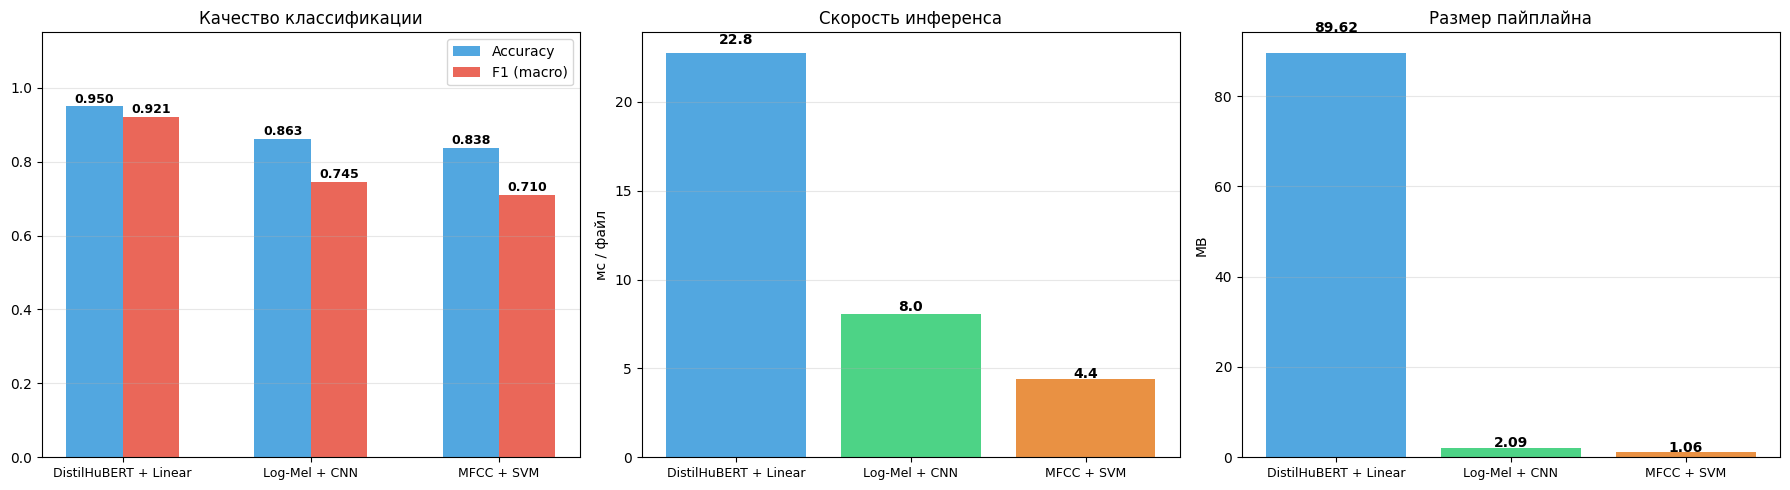

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = df["Модель"].tolist()
x = np.arange(len(models))
colors = ["#3498db", "#2ecc71", "#e67e22"]

# ── Качество ──
w = 0.3
b1 = axes[0].bar(x - w / 2, df["Accuracy"], w,
                  label="Accuracy", color="#3498db", alpha=0.85)
b2 = axes[0].bar(x + w / 2, df["F1 (macro)"], w,
                  label="F1 (macro)", color="#e74c3c", alpha=0.85)
axes[0].set_ylim(0, 1.15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_title("Качество классификации")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for b in list(b1) + list(b2):
    axes[0].text(
        b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
        f"{b.get_height():.3f}", ha="center", fontsize=9, fontweight="bold",
    )

# ── Скорость инференса ──
b3 = axes[1].bar(x, df["Инференс (мс/файл)"], color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].set_ylabel("мс / файл")
axes[1].set_title("Скорость инференса")
axes[1].grid(axis="y", alpha=0.3)
for b in b3:
    axes[1].text(
        b.get_x() + b.get_width() / 2, b.get_height() * 1.02,
        f"{b.get_height():.1f}", ha="center", fontsize=10, fontweight="bold",
    )

# ── Размер пайплайна ──
b4 = axes[2].bar(x, df["Пайплайн (MB)"], color=colors, alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, fontsize=9)
axes[2].set_ylabel("MB")
axes[2].set_title("Размер пайплайна")
axes[2].grid(axis="y", alpha=0.3)
for b in b4:
    axes[2].text(
        b.get_x() + b.get_width() / 2, b.get_height() * 1.05,
        f"{b.get_height():.2f}", ha="center", fontsize=10, fontweight="bold",
    )

plt.tight_layout()
plt.show()